# Week 6: The Finite Difference Method & Quantum Mechanics

## Library Imports Go Here

In [115]:
import numpy as np
import matplotlib.pyplot as plt
import time
import scipy.sparse as sparse
import scipy.sparse.linalg as linalg
from scipy.sparse.linalg import eigsh

## Generic Finite Difference Code


    
The essence of the finite difference method is that it allows us to replace an expression involving spatial derivatives such as

$$
A(x)\psi'' + B(x)\psi' + C(x)\psi
$$

subject to the boundary conditions

$$
\psi(x_{\mathrm{left}}) = \psi(x_{\mathrm{right}}) = 0
$$

with a linear algebra expression in which "$\psi(x)$" becomes a vector $\vec{\psi}$ of $N$ components, and the full expression is represented as

$$
\mathbb{M}\vec{\psi}
$$

where $\mathbb{M}$ is a $N \times N$ matrix.  This expression then appears in various different types of differential equations, which we can then use linear algebra to solve.

The most challenging aspect of this is generating the matrix $\mathbb{M}$.

### A Spatial Grid Function


    
Write a (simple) function that takes as inputs the numerical parameters $x_{\mathrm{left}}$, $x_{\mathrm{right}}$, and $N$ and outputs an array of positions $\{x_1, x_2, ..., x_N\}$ for use in the finite difference method.  Remember that the grid does *not* include the boundary values $x_{\mathrm{left}}$ and $x_{\mathrm{right}}$ themselves.  Test your code using the choices

$$
x_{\mathrm{left}} = 1, \hspace{.5in} x_{\mathrm{right}} = 2, \hspace{.5in} N = 4
$$

and as a **discussion**, confirm that the output is correct.

In [102]:
def spatial(x_left, x_right, N):
    return np.linspace(x_left, x_right, N+2)[1:-1]

spatial(1,2,4)

array([1.2, 1.4, 1.6, 1.8])

### A Projection Function



Now write a function that takes as inputs a function f(x) and a spatial grid (that is, a numpy array) $\{x_1, x_2, \dots, x_N\}$, and outputs a numpy array of that function projected onto the grid: $\{f(x_1), f(x_2), \dots, f(x_N)\}$.  Test your code using the same grid as above, and with the two functions

$$
f_{(1)}(x) = x^2 \,, \hspace{1in} 
f_{(2)}(x) =
\begin{cases}
  0 & \text{for } x < 1.5 \\
  1 & \text{for } x \ge 1.5
\end{cases}
$$


As a **discussion** confirm that your outputs are correct.

In [103]:
def proj(f, grid):
    return np.array([f(grid[i]) for i in range(len(grid))], dtype=float)

def f(x):
    return float(x**2)

grid = spatial(1,2,4)
proj(f, grid)

array([1.44, 1.96, 2.56, 3.24])

### A Matrix Generating Function

#### Creating the Matrix



Construct a function that takes as inputs the three functions $A(x)$, $B(x)$, and $C(x)$, along with the spatial grid array, and outputs the matrix $\mathbb{M}$ (as an array.)  

Hints:  

1)  The positions "x" at which you need to evaluate the functions A, B, and C, are the values in the input array, with the position in the array corresponding to the row of the matrix.

2)  You can extract the values $\Delta$ and $N$ from the grid itself.

3)  You may (or may not) find it useful to use your projection function here.

In [104]:
def matrix(A, B, C, grid):
    del_x = grid[1] - grid[0]
    x_int = grid
    N = len(x_int)

    a = proj(A, x_int) 
    b = proj(B, x_int)  
    c = proj(C, x_int)  

    M = np.zeros((N, N))

    for i in range(N):
        M[i, i] = c[i] - ((2 * a[i]) / (del_x**2))

    for i in range(1, N):
        M[i, i-1] = (a[i] / (del_x**2)) - (b[i] / (2 * del_x))
    for i in range(0, N-1):
        M[i, i+1] = (a[i] / (del_x**2)) + (b[i] / (2 * del_x))

    return M

#### Testing for Predictable Results



Consider the functions

$$
A(x) = 2x \, , \hspace{.5in} B(x) = x^2 \, , \hspace{.5in} C(x) = 1
$$

and the grid with $x_{\mathrm{left}} = 1$, $x_{\mathrm{right}} = 2$, and $N = 4$.

As a **discussion**, work out what each component of the matrix should be.  Then, confirm your results are correct.  (Yes, this is a bit tedious.  But it is very common to get this code wrong in small, subtle ways, and this test is designed to protect against that).

In [105]:
def A(x):
    return 2*x
def B(x):
    return x**2
def C(x):
    return 1

grid = spatial(1, 2, 4)
matrix(A, B, C, grid)

array([[-119. ,   63.6,    0. ,    0. ],
       [  65.1, -139. ,   74.9,    0. ],
       [   0. ,   73.6, -159. ,   86.4],
       [   0. ,    0. ,   81.9, -179. ]])

### A Sparse Matrix Generating Function



You will notice that the matrix we are generating has a lot of zeroes in it, particularly when the value $N$ is large.  Creating and storing a matrix with a lot of zero values wastes memory in the computer, and requires more time to do anything with, than it really should.

A better approach is to create and store the matrix we are building as a type of "sparse array" in the `scipy.sparse` library known as a `coo_matrix`, which keeps track only of the entries that are non-zero, and the locations of those entries.  For example, the matrix

$$
\left[\begin{array}{cccc} 0 & 0 & 0 & 0 \\ 0 & 0 & 87 & 0 \\ 0 & 0 & 0 & 0 \\ 0 & 23 & 0 & 0 \end{array}\right]
$$

is stored simply as

$$
\begin{array}{ccc}
(1, 2) & \hspace{.5in} & 87 \\
(3, 1) & \hspace{.5in} & 23
\end{array}
$$

(The first non-zero element of the array is at row 1 and column 2, and has value 87.  The second non-zero element of the array is at row 3 and column 1, and has value 23).  All told, the computer needs to store 6 numbers using this construction, as opposed to the 16 it stores if we build it as a normal array.

To create a coo_matrix, we can use the command

`coo_matrix((data, (rows, columns)), shape = (N, N)`

where `data`, `rows`, and `columns` are each arrays of values.  For example, the above matrix has:

`data = np.array([87, 23])`

`rows = np.array([1, 3])`

`columns = np.array([2, 1])`

Your next job is to write a function that produces a sparse array version of the same matrix as before, but we will break it into steps to make the task more manageable.

#### A Very Simple Test


    
Begin by testing out this new object by constructing the sparse matrix described above -- make arrays of the rows, columns, and data values, and use those as inputs to the `coo_matrix` command.  To check that your results are correct:

1)  Print out the sparse matrix you have constructed.

2)  Convert that matrix into a normal array using the command `.toarray()`, and print that out as well.

#### Diagonal Elements


    
Now write a function whose outputs will be just the three arrays of rows, columns, and data values necessary to create just the *diagonal* elements of the matrix $\mathbb{M}$ we are interested in.  

It should take as inputs the functions $A(x)$ and $C(x)$, along with the grid itself.  You may (or may not) find it useful to use your projection function here.

Test it out using the same grid and functions you used to test your first matrix making function.  Take the outputs of the function and use them to create a sparse-matrix, and confirm the values are the same as in the previous function.

**Note**:  The point of using the sparse matrices is to increase efficiency -- so make sure you're not using "append" to build your arrays here!

In [106]:
def diag(A, C, grid):
    x = np.asarray(grid, dtype=float)
    del_x = x[1] - x[0]

    N = x.size
    rows = np.arange(N)
    cols = rows 

    a = np.array([A(xi) for xi in x], dtype=float) 
    c = np.array([C(xi) for xi in x], dtype=float)
    data = c - (2.0 * a) / (del_x**2)

    return rows, cols, data

#### Off-Diagonals


    
Now create two more functions to produce the upper and lower off-diagonals.  Again, each function should output the arrays of rows, columns, and data values necessary as inputs to the function `coo_matrix`.  These functions should have as inputs the functions A(x) and B(x), along with the spatial grid.

Test your functions again using the choices of A, B, and C and the spatial grid used earlier, and again use the results to create sparse matrices and compare them with your previous matrix generating code.

In [107]:
def upper(A, B, grid):
    x = np.asarray(grid, dtype=float)
    del_x = x[1] - x[0]
    N = len(x)

    rows = np.array([i for i in range(0, N-1)])
    cols = np.array([i+1 for i in range(0, N-1)])

    a = np.array([A(x[i]) for i in range(0, N-1)], dtype=float)
    b = np.array([B(x[i]) for i in range(0, N-1)], dtype=float)

    data = (a / (del_x**2)) + (b / (2.0 * del_x))
    return rows, cols, data

def lower(A, B, grid):
    x = np.asarray(grid, dtype=float)
    del_x = x[1] - x[0]
    N = len(x)

    rows = np.array([i for i in range(1, N)])
    cols = np.array([i-1 for i in range(1, N)])

    a = np.array([A(x[i]) for i in range(1, N)], dtype=float)
    b = np.array([B(x[i]) for i in range(1, N)], dtype=float)

    data = (a / (del_x**2)) - (b / (2.0 * del_x))
    return rows, cols, data


#### The Sparse Matrix Maker


    
Now create the full code to produce your sparse matrix.

1)  This function should take as inputs the functions A, B, C and the spatial grid

2)  It should *call* the functions you have just written to produce arrays of rows, columns, and data corresponding to different parts of the full matrix

3)  You can then use the `numpy` command `concatenate` to (efficiently) combine multiple arrays into a single array.

4)  The function should output the matrix as a `coo_matrix`.

Once again, test your function using the same A, B, and C functions and the same spatial grid.

In [108]:
def sparseMatrixMaker(A, B, C, grid):
    rD, cD, dD = diag(A, C, grid)
    rU, cU, dU = upper(A, B, grid)
    rL, cL, dL = lower(A, B, grid)

    rows = np.concatenate([rD, rU, rL])
    cols = np.concatenate([cD, cU, cL])
    data = np.concatenate([dD, dU, dL])

    N = len(grid)
    return sparse.coo_matrix((data, (rows, cols)), shape=(N, N))

print(sparseMatrixMaker(A, B, C, grid))

<COOrdinate sparse matrix of dtype 'float64'
	with 10 stored elements and shape (4, 4)>
  Coords	Values
  (0, 0)	-119.00000000000006
  (1, 1)	-139.00000000000006
  (2, 2)	-159.00000000000009
  (3, 3)	-179.00000000000009
  (0, 1)	63.60000000000003
  (1, 2)	74.90000000000003
  (2, 3)	86.40000000000005
  (1, 0)	65.10000000000002
  (2, 1)	73.60000000000004
  (3, 2)	81.90000000000003


### Comparing Efficiency



Now we want to compare the efficiency of working with these two types of matrices.  

#### An Analytic Argument


As a **discussion**, compute the total number of values stored to make an $N \times N$ matrix $\mathbb{M}$ using each of the two methods.  Based on this, what do you expect to see when you look at timing behaviors?

For the normal method, you store exactly $N^2$ numbers.

For the sparse array method, you store 3 numbers for each non-zero element of the matrix.  The total number of non-zero elements is $3N - 2$, so the total number of numbers stored is $9N - 6$.

We can see that as $N$ becomes large, the time required to create the normal matrix should grow quadratically, while the time required to create a sparse matrix should grow linearly.  This means that for large matrices the sparse matrix should be much more efficient -- though for smaller matrices it won't necessarily be.

#### Timing Functions



Write a function that takes as input the value $N$, and returns the amount of time required to build the matrix $\mathbb{M}$ using your original matrix generating function.

Then, do the same thing for your sparse matrix generating function.

In [109]:
def timing_matrix(N):
    N = int(N)
    grid = spatial(1,2,N)
    start = time.time()
    matrix(A, B, C, grid)
    end = time.time()
    matrix_time = end - start
    return matrix_time

def timing_sparse(N):
    N = int(N)
    grid = spatial(1,2,N)
    start1 = time.time()
    sparseMatrixMaker(A, B, C, grid)
    end1 = time.time()
    sparse_time = end1 - start1
    return sparse_time

#### Timing Data



Create an array of values of $N$ between 10 and 1000 in steps of 10.  Then, create associated timing arrays for the two different matrix makers.

In [110]:
N_values = np.arange(10, 1011, 10)
timing_array_matrix = np.zeros(len(N_values))
timing_array_sparse = np.zeros(len(N_values))

for i in range(len(N_values)):
    timing_array_matrix[i] = timing_matrix(N_values[i])

for i in range(len(N_values)):
    timing_array_sparse[i] = timing_sparse(N_values[i])

#### Graphical Comparison



Create a graph of your timing data so that you can compare the two methods.

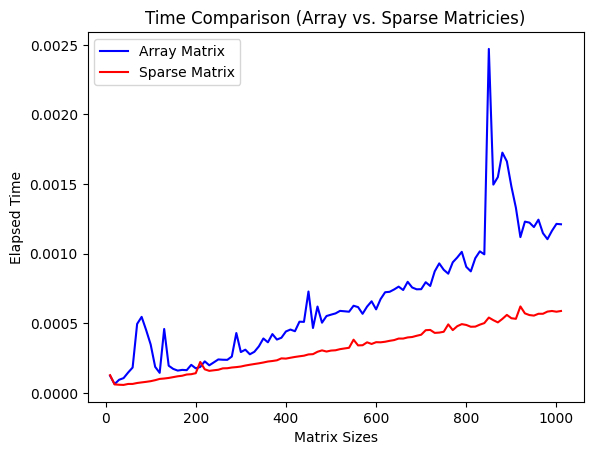

In [111]:
plt.plot(N_values, timing_array_matrix, color = 'b', label = 'Array Matrix')
plt.plot(N_values, timing_array_sparse, color = 'r', label = 'Sparse Matrix')
plt.title('Time Comparison (Array vs. Sparse Matricies)')
plt.xlabel('Matrix Sizes')
plt.ylabel('Elapsed Time')
plt.legend()
plt.show()

## Energy Eigenstates and Eigenvalues in Quantum Mechanics


    
Our first use for the finite difference method will be in solving for states of definite energy (and the energies themselves) in 1D quantum mechanics.  In this case, our specific math problem is written (in ND form) as

$$
-\frac{1}{2}\frac{d^2\psi}{d\tilde{x}^2} + \tilde{V}(\tilde{x})\psi = \tilde{E}\psi
$$
where we assume the wavefunction satisfies boundary conditions
$$
\psi(\pm\infty) = 0
$$
and we want to find both the energies $\tilde{E}$ and the associated states $\psi$ that solve this problem.


Once we have used the finite difference method to convert this into a linear algebra problem, it reads
$$
\mathbb{H}\vec{\psi} = \tilde{E}\vec{\psi}
$$

and we want to find the eigenvalues $\tilde{E}_{(k)}$ and eigenvectors $\vec{\psi}_{(k)}$ that solve the problem.  To do this, we will be using the function `scipy.sparse.linalg.eigsh`, intsead of writing our own code.  (Notice that this function will work directly with matrices in "sprarse" form).

### The Hamilonian Matrix



First we want to write the code that generates the matrix $\mathbb{H}$.  This code should take as inputs just the potential function $V(\tilde{x})$, and the numerical grid parameters $\tilde{x}_{\infty}$ and $N$, and then *call the functions you wrote in the previous section* to construct and output the matrix as a sparse matrix.

Note that in this case, our grid endpoints will be $-x_{\infty}$ and $+x_{\infty}$ (they both use the same numerical parameter).

In [114]:
def hamiltonian(V, x_inf, N):
    N = int(N)
    grid = spatial(-x_inf, x_inf, N)

    def A(x):
        return -0.5
    def B(x):
        return 0.0
    def C(x):
        return V(x)
    
    return sparseMatrixMaker(A, B, C, grid).tocsr()

### The Simple Harmonic Oscillator


    
Now we're going to specialize to the case

$$
V(\tilde{x}) = \frac{1}{2}\tilde{x}^2
$$

which is the (non-dimensionalized) quantum simple harmonic oscillator.  In this case, the problem of finding the states of definite energy and their energies has an analytic solution.  The energy spectrum is given by

$$
\tilde{E}_{(n)} = \frac{1}{2} + n \, , \hspace{.5in} n = 0, 1, 2, 3, \dots \, .
$$

The lowest three corresponding states are

$$
\psi_{(0)}(\tilde{x}) = \frac{1}{\pi^{1/4}} \, e^{-\tilde{x}^2/2}
\hspace{.75in}
\psi_{(1)}(\tilde{x}) = \frac{\sqrt{2}}{\pi^{1/4}} \, \tilde{x} \, e^{-\tilde{x}^2/2}
\hspace{.75in}
\psi_{2}(\tilde{x}) = \frac{\sqrt{2}}{\pi^{1/4}} \, \left(\tilde{x}^2 - \frac{1}{2}\right) \, e^{-\tilde{x}^2/2}
$$

#### The Eigenvalues



Use your code to generate the Hamiltonian matrix for the QSHO problem, with grid parameters $x_{\infty} = 100$ and $N = 100000$. Then, use the function `eigsh` from `scipy.sparse.linalg` to find the lowest 10 eigenvalues.  

Create a plot that shows those eigenvalues vs. the quantum number $n$, and on the same graph plot the theoretical values.  Confirm that they agree.

**Note** read the documentation for this function carefully: notice that the number of eigenvalues you get out is an input parameter, as is a parameter called "sigma", which determines whether the eigenvalues you get start with the smallest value, or with the largest.  Notice also that the *output* includes both the eigenvalues, and the eigenvectors.

Numerical  : [0.49999988 1.49999938 2.49999838 3.49999688 4.49999488 5.49999238
 6.49998938 7.49998588 8.49998188 9.49997738]
Theoretical: [0.5 1.5 2.5 3.5 4.5 5.5 6.5 7.5 8.5 9.5]
max |ΔE|   : 2.2624566607731822e-05


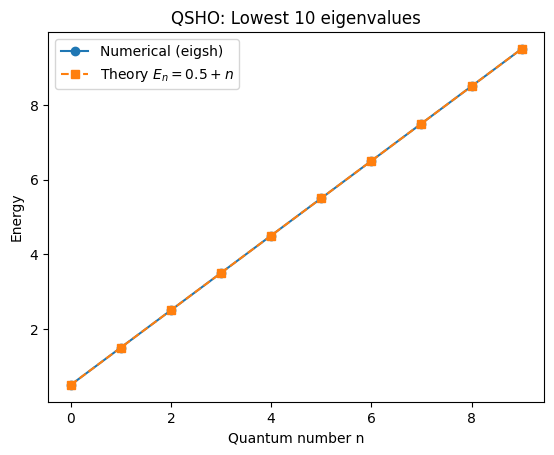

In [123]:
def V(x):
    return 0.5 * x**2

k = 10
H = hamiltonian(V, 100, 100000)
E = eigsh(H, k=k, which='SA', return_eigenvectors=False)

E_num, E_vec = eigsh(H, k=k, sigma=0.0, which='LM')

idx = np.argsort(E_num)
E_num = E_num[idx]

n = np.arange(k)
E_th = 0.5 + n

print("Numerical  :", E_num)
print("Theoretical:", E_th)
print("max |ΔE|   :", np.max(np.abs(E_num - E_th)))

plt.figure()
plt.plot(n, E_num, marker='o', linestyle='-', label='Numerical (eigsh)')
plt.plot(n, E_th,  marker='s', linestyle='--', label='Theory $E_n=0.5+n$')
plt.xlabel('Quantum number n')
plt.ylabel('Eigenvalue')
plt.title('QSHO: Lowest 10 eigenvalues')
plt.legend()
plt.show()

#### The Low-Lying States



Now, examine the eigenstates.  Create three graphs showing the lowest three numerical eigenstates, together with the analytic predictions for them.  Note that:

1)  The eigenvectors that come out of `eigsh` are organized into a matrix where each *column* of the matrix is a different vector (not each row).

2)  The eigenvectors have components $\psi_i = \psi(x_i)$ where $x_i$ are the positions on the spatial grid.  

3)  The eigenvectors are normalized "as vectors", which follows a different rule than the wavefunction states do -- to correct for this you will need to multiply each vector by an additional constant that you can tune by hand (and that constant may be negative!)

/var/folders/kh/9s_l3rg91_951phmfvtb4q6r0000gn/T/ipykernel_33634/2330207441.py:20: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  sign = 1.0 if np.trapz(psi_num[:, i] * psi_th[i], x) >= 0 else -1.0


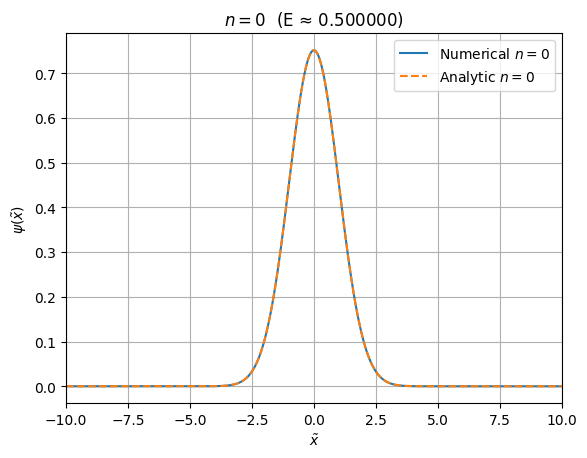

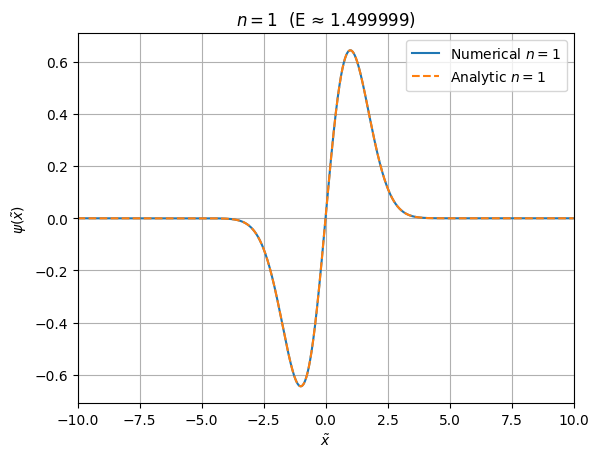

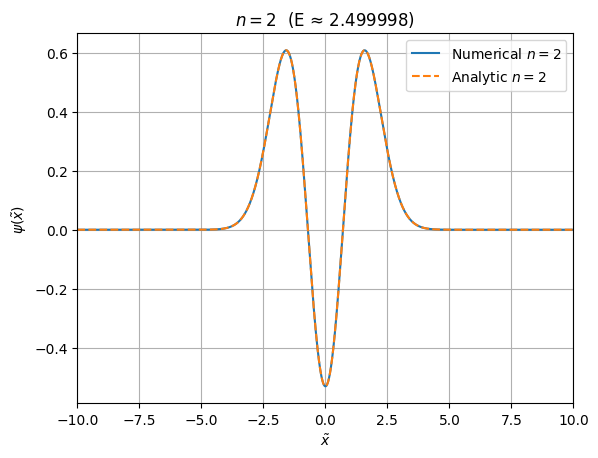

In [127]:
x_inf = 100
N = 100000
k = 3

x  = spatial(-x_inf, x_inf, N)
dx = x[1] - x[0]
E, vecs = eigsh(H, k=k, sigma=0.0, which='LM')
idx = np.argsort(E)
E = E[idx]
vecs = vecs[:, idx]

psi_num = vecs / np.sqrt(dx)

psi0 = (np.pi**-0.25) * np.exp(-0.5 * x**2)
psi1 = (np.sqrt(2) * np.pi**-0.25) * x * np.exp(-0.5 * x**2)
psi2 = (np.sqrt(2) * np.pi**-0.25) * (x**2 - 0.5) * np.exp(-0.5 * x**2)
psi_th = [psi0, psi1, psi2]

for i in range(k):
    sign = 1.0 if np.trapz(psi_num[:, i] * psi_th[i], x) >= 0 else -1.0
    psi_num[:, i] *= sign

labels = [r"$n=0$", r"$n=1$", r"$n=2$"]
for j in range(k):
    plt.figure()
    plt.plot(x, psi_num[:, j], label=f"Numerical {labels[j]}")
    plt.plot(x, psi_th[j], '--', label=f"Analytic {labels[j]}")
    plt.xlabel(r"$\tilde{x}$"); plt.ylabel(r"$\psi(\tilde{x})$")
    plt.title(f"{labels[j]}  (E ≈ {E[j]:.6f})")
    plt.legend(); plt.grid(True)
    plt.xlim(-10, 10)
    plt.show()

#### The Grid Parameter $\Delta$



Now we want to examine the significance of the numerical parameters, starting with $\Delta$.  Using the $n = 9$ state of the QSHO, find and plot this state for four different choices of $N$, while leaving $x_{\infty} = 100$:

$N = 200, 400, 800, 1600, 3200$

As a **discussion** compute $\Delta$ for each of these cases, and examine the effect of gradually increasing $\Delta$ on the method: what needs to be true in order for the method to "do a good job" of approximating the state?

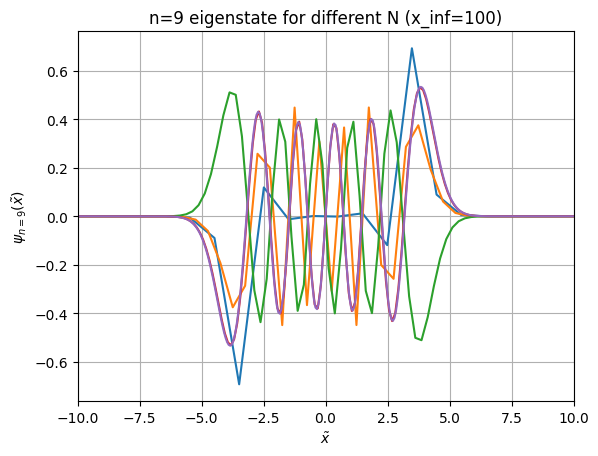

N= 200  Δ = 0.995024875622
N= 400  Δ = 0.498753117207
N= 800  Δ = 0.249687890137
N=1600  Δ = 0.124921923798
N=3200  Δ = 0.062480474852


In [139]:
x_inf = 100
N_values = [200, 400, 800, 1600, 3200]
target_E = 9 

plt.figure()
deltas = []

for N in N_values:
    x  = spatial(-x_inf, x_inf, N)
    dx = x[1] - x[0]
    deltas.append(dx)

    H = hamiltonian(V, x_inf, N)

    E, vec = eigsh(H, k=1, sigma=target_E, which='LM')   
    psi = vec[:, 0] / np.sqrt(dx)            

    # fix global sign for consistent positive
    jmax = np.argmax(np.abs(psi))
    psi *= np.sign(psi[jmax]) if psi[jmax] != 0 else 1.0

    plt.plot(x, psi, label=f"N={N}, Δ≈{dx:.5f}")

plt.xlabel(r"$\tilde{x}$")
plt.ylabel(r"$\psi_{n=9}(\tilde{x})$")
plt.title("n=9 eigenstate for different N (x_inf=100)")
plt.xlim(-10,10)
plt.grid(True)
plt.show()

# Print the Δ values for discussion
for N, dx in zip(N_values, deltas):
    print(f"N={N:4d}  Δ = {dx:.12f}")


#### The Grid Parameter $x_{\infty}$



Now we want to examine the effect of changing $x_{\infty}$, while leaving $\Delta = 0.01$ fixed.    Create a graph that shows the $n = 9$ state with $x_{\infty} = \{100, 50, 10, 5, 1\}$.  For each case, you will also need to work out the value of $N$ necessary to leave $\Delta = 0.01$.

Then **discuss** the results.  What needs to be true of $x_{\infty}$ in order for the method to "do a good job" on the state?

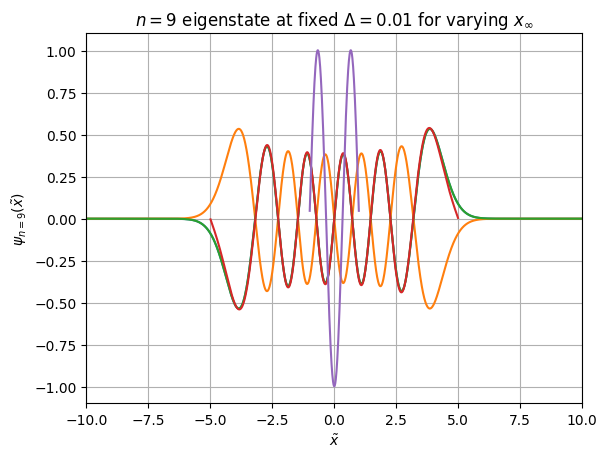

x_inf=  100  N= 19999  Δ=0.01000000  E≈9.49943434
x_inf=   50  N=  9999  Δ=0.01000000  E≈9.49943434
x_inf=   10  N=  1999  Δ=0.01000000  E≈9.49943434
x_inf=    5  N=   999  Δ=0.01000000  E≈9.53598200
x_inf=    1  N=   199  Δ=0.01000000  E≈11.25677099


In [141]:
delta = 0.01
x_infs = [100, 50, 10, 5, 1] 
n_target = 9
sigma = 0.5 + n_target 

plt.figure()
computed_info = []

for x_inf in x_infs:
    N = int(round(2.0 * x_inf / delta - 1.0))
    x = spatial(-x_inf, x_inf, N) 
    dx = x[1] - x[0]

    H = hamiltonian(V, x_inf, N)

    E, vec = eigsh(H, k=1, sigma=sigma, which='LM') 
    psi = vec[:, 0] / np.sqrt(dx)                  

    jmax = np.argmax(np.abs(psi))
    if psi[jmax] < 0:
        psi = -psi

    plt.plot(x, psi, label=f"$x_\\infty$={x_inf}, N={N}, Δ≈{dx:.5f}")
    computed_info.append((x_inf, N, dx, E[0]))

plt.xlabel(r"$\tilde{x}$")
plt.ylabel(r"$\psi_{n=9}(\tilde{x})$")
plt.title(r"$n=9$ eigenstate at fixed $\Delta=0.01$ for varying $x_\infty$")
plt.xlim(-10,10)
plt.grid(True)
plt.show()

for x_inf, N, dx, E in computed_info:
    print(f"x_inf={x_inf:>5}  N={N:>6}  Δ={dx:.8f}  E≈{E:.8f}")


### Comparing Potentials*



Now we want to look at how changing the potential energy function (the physical system our particles are in) affects the energies and states.  We will consider two other potentials (neither of which can be approached analytically), to compare with the SHO potential:

$$
\tilde{V}_{SHO}(\tilde{x}) = \frac{1}{2}\tilde{x}^2 \, , \hspace{.5in} \tilde{V}_{abs}(\tilde{x}) = |\tilde{x}| \, , \hspace{.5in} \tilde{V}_{quad}(\tilde{x}) = \frac{1}{4} \tilde{x}^4
$$

In your discussions, think about what is *the same*, and what is *different* as you change the potentials.  Also think about what the behavior of the potentials would imply classically, and how that is (or isn't) reflected in the quantum mechanical results.

#### The Potentials Themselves



Begin by simply plotting these three potentials together, so that you can see the ways in which they are similar, and the ways in which they are different.

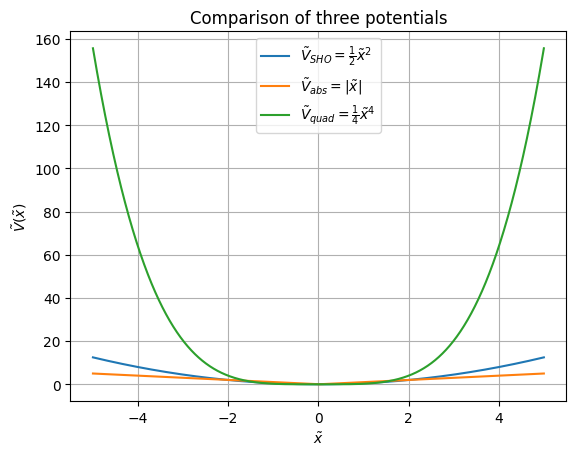

In [155]:
x_inf = 5.0
N = 2000

x = spatial(-x_inf, x_inf, N)

V_sho = 0.5 * x**2
V_abs = np.abs(x)
V_quad = 0.25 * x**4

plt.figure()
plt.plot(x, V_sho, label=r"$\tilde{V}_{SHO}=\frac{1}{2}\tilde{x}^2$")
plt.plot(x, V_abs, label=r"$\tilde{V}_{abs}=|\tilde{x}|$")
plt.plot(x, V_quad, label=r"$\tilde{V}_{quad}=\frac{1}{4}\tilde{x}^4$")
plt.xlabel(r"$\tilde{x}$")
plt.ylabel(r"$\tilde{V}(\tilde{x})$")
plt.title("Comparison of three potentials")
plt.grid(True)
plt.legend()
plt.show()

#### The Energy Spectra


Now find the lowest ten energy eigenvalues for each of the three potentials, and create a plot that shows all three energy spectra together.  **Discuss** the physics of what you see thoroughly (and keep in mind the differences in the potentials themselves as you do!)  Use the grid parameters $x_{\infty} = 100$ and $N = 100000$.

In [ ]:
def V_sho(x):  return 0.5 * x**2
def V_abs(x):  return np.abs(x)
def V_quad(x): return 0.25 * x**4

[12.47502498 12.45007494 12.42514987 ... 12.42514987 12.45007494
 12.47502498]
SHO (1/2x^2): [0.49999988 1.49999938 2.49999838 3.49999688 4.49999488 5.49999238
 6.49998938 7.49998588 8.49998188 9.49997738]
|x|: [0.80861655 1.85575662 2.57809528 3.24460622 3.82571335 4.38166868
 4.89181712 5.38660991 5.85129642 6.30525771]
1/4 x^4: [ 0.42080483  1.50790017  2.95879207  4.62121183  6.45349365  8.42842634
 10.52778802 12.73827455 15.04966602 17.45381743]


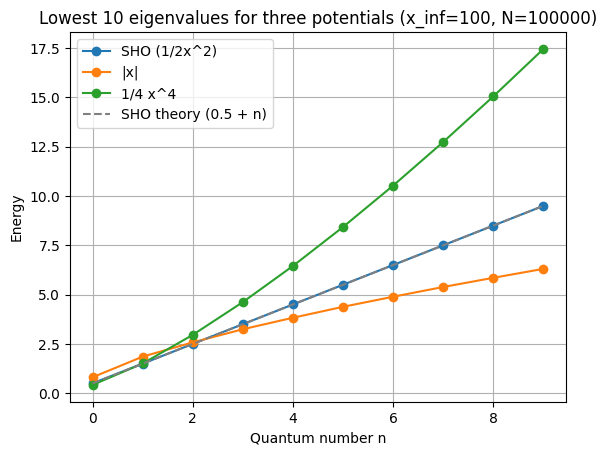

In [ ]:
x_inf = 100
N = 100000
k = 10
n = np.arange(k)

spectra = {}

for name, Vfunc in [("SHO (1/2x^2)", V_sho), ("|x|", V_abs), ("1/4 x^4", V_quad)]:
    H = hamiltonian(Vfunc, x_inf, N).tocsr()
    E = eigsh(H, k=k, which='SA', return_eigenvectors=False)
    E.sort()
    spectra[name] = E
    #print(f"{name}: {E}")


plt.figure()
for name, E in spectra.items():
    plt.plot(n, E, marker='o', label=name)

plt.plot(n, 0.5 + n, linestyle='--', color='gray', label='SHO theory (0.5 + n)')
plt.xlabel('Quantum number n')
plt.ylabel('Energy')
plt.title('Lowest 10 eigenvalues for three potentials (x_inf=100, N=100000)')
plt.grid(True)
plt.legend()
plt.show()


#### The Eigenstate Wavefunctions



Now we want to explore the wavefunctions themselves.  Create a graph that shows the ground state wavefunction for each of the three potentials.  Then do the same for the $n = 1$ and $n = 2$ states.  Again, **discuss** the physics of the results thoroughly.

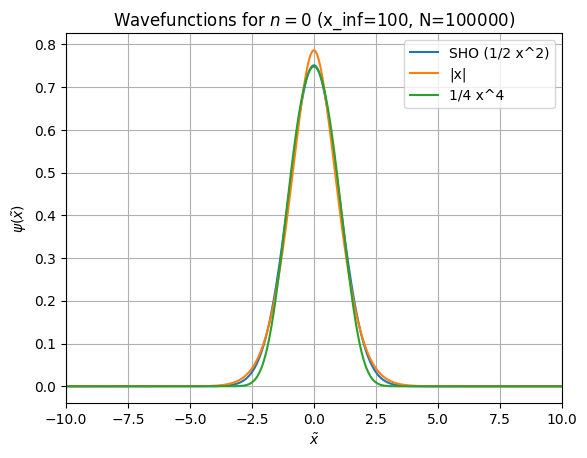

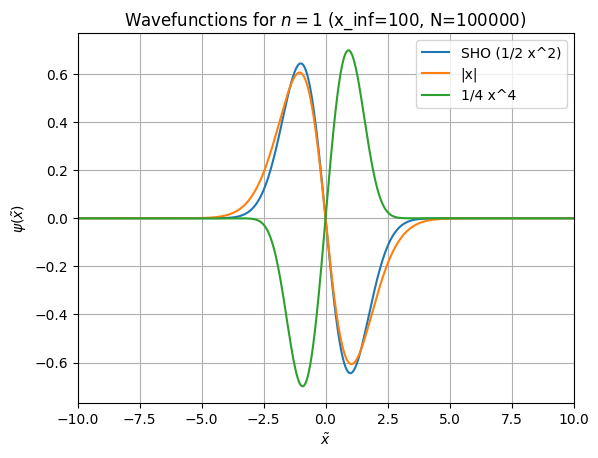

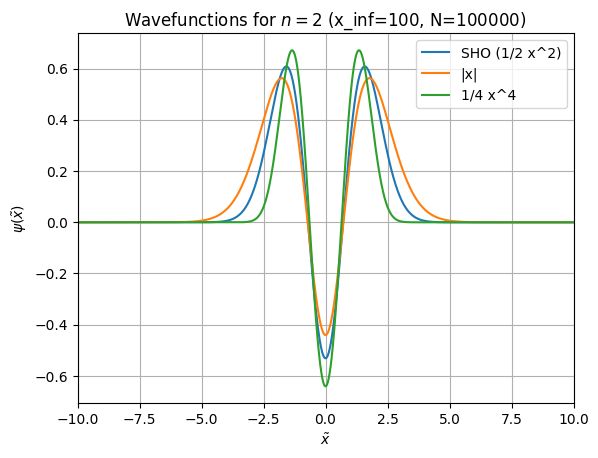

SHO (1/2 x^2) : [0.49999988 1.49999938 2.49999838]
|x| : [0.80861655 1.85575662 2.57809528]
1/4 x^4 : [0.42080483 1.50790017 2.95879207]


In [160]:
x_inf = 100
N = 100_000
k = 3  
potentials = [("SHO (1/2 x^2)", V_sho), ("|x|", V_abs), ("1/4 x^4", V_quad)]

x  = spatial(-x_inf, x_inf, N) 
dx = x[1] - x[0]

eigvals = {}
eigvecs = {}

for name, Vfunc in potentials:
    H = hamiltonian(Vfunc, x_inf, N).tocsr()

    E, vecs = eigsh(H, k=k, sigma=0.0, which='LM')  
    idx = np.argsort(E)
    E   = E[idx]
    vecs = vecs[:, idx]

    vecs = vecs / np.sqrt(dx)

    for j in range(k):
        jm = np.argmax(np.abs(vecs[:, j]))
        if vecs[jm, j] < 0:
            vecs[:, j] *= -1

    eigvals[name] = E
    eigvecs[name] = vecs

labels_n = [r"$n=0$", r"$n=1$", r"$n=2$"]
for j in range(k):
    plt.figure()
    for name, _ in potentials:
        plt.plot(x, eigvecs[name][:, j], label=name)
    plt.xlabel(r"$\tilde{x}$")
    plt.ylabel(r"$\psi(\tilde{x})$")
    plt.title(f"Wavefunctions for {labels_n[j]} (x_inf={x_inf:.0f}, N={N})")
    plt.legend()
    plt.xlim(-10,10)
    plt.grid(True)
    plt.show()

for name in eigvals:
    print(name, ":", eigvals[name])